In [1]:
import numpy as np
import pandas as pd
import cvxpy as cp
import seaborn as sns
import mosek
import matplotlib.pyplot as plt
import datetime as date
from datetime import datetime as dt
from dateutil.relativedelta import *
import scipy.stats
from scipy.stats import rankdata

In [44]:
def argmax_pwfunc(x2,x1,r):
    frac = (x2**r-x1**r)/(x2-x1)*1/r
    return(frac**(1/(r-1)))

def eval_max_pwfunc(x2,x1,x,r):
    frac = (x2**r-x1**r)/(x2-x1)
    return(x**r-frac*(x-x1)-x1**r)

def pwfunc (x,r):
    return(x**r)

def pw_affine_approx(eps,r):
    x_points = [0]
    x1 = 0
    error = np.inf
    x2 = 1
    x2_l = 0
    x2_r = 1
    continu = True
    while continu:
        x = argmax_pwfunc(x2,x1,r)
        error = eval_max_pwfunc(x2,x1,x,r)
        if np.abs(1-x2)<= 0.0001:
            if error < eps:
                break
        if np.abs(error-eps)<= 0.0001:
            x_points.append(x2)
            x1 = x2
            x2_l = x1
            x2 = 1
            x2_r = 1
        elif error > eps:
            x2_r = x2
            x2 = (x2+x2_l)/2
        elif error < eps:
            x2_l = x2
            x2 = (x2+x2_r)/2
    x_points.append(1)
    return(np.array(x_points))
    

In [50]:
eps = 0.01
r = 0.5
x_points = pw_affine_approx(eps,r)
    


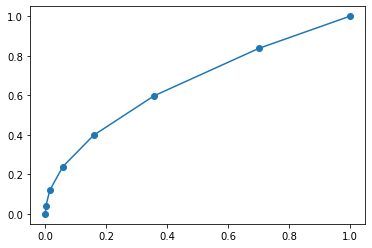

In [51]:
y_points=np.array(x_points)**r
plt.plot(x_points, y_points, "-o")

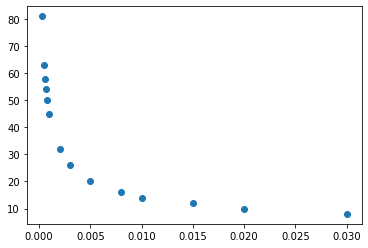

In [60]:
eps_set = [0.0003, 0.0005,0.0006,0.0007, 0.0008, 0.001, 0.002, 0.003, 0.005,0.008,0.01,0.015,0.02,0.03]
K = []
r = 0.2
for eps in eps_set:
    x_points = pw_affine_approx(eps,r)
    K.append(len(x_points))
K = np.array(K)
plt.plot(np.array(eps_set),K,'o')
    